In [1]:
# %matplotlib widget

import os
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import shap
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import fdrcorrection

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import make_scorer, precision_score, recall_score, classification_report, ConfusionMatrixDisplay, f1_score, make_scorer, RocCurveDisplay
from itertools import combinations

def precision_class_0(y_true, y_pred):
    return precision_score(y_true, y_pred, average=None)[0]

def precision_class_1(y_true, y_pred):
    return precision_score(y_true, y_pred, average=None)[1]

def recall_class_0(y_true, y_pred):
    return recall_score(y_true, y_pred, average=None)[0]

def recall_class_1(y_true, y_pred):
    return recall_score(y_true, y_pred, average=None)[1]

import warnings
import anndata
import scanpy as sc


In [2]:
os.getcwd()

'/workspace/ML/XAI'

In [3]:
os.chdir("../Store/")
os.getcwd()

'/workspace/ML/Store'

In [28]:
def addGeneClusters(geneDict, folder):
    clusters = joblib.load(f"{folder}/uniqueClusters.pkl")
    resultValues = list(geneDict.values())
    resultKeys = list(geneDict.keys())

    for key, gene in clusters.items():
        
        if gene in resultKeys:
            insertGenes = [k for k in key if k != gene]
            idx = resultKeys.index(gene)
            resultValues[idx+1:idx+1] = [resultValues[idx]] * len(insertGenes)
            resultKeys[idx+1:idx+1] = insertGenes


    return dict(zip(resultKeys, resultValues))

In [30]:
csf_importance = joblib.load("CSF_BCELLS/xgbCSFBCELLS_feature_importance.pkl")
csf_importance = pd.Series(csf_importance["MeanAbsoluteShap"].values, index=csf_importance["Feature"]).to_dict()
csf_importance = addGeneClusters(csf_importance, "CSF_BCELLS")

pbmc_importance = joblib.load("PBMC_BCELLS_2DATASET/xgbPBMCBCELLS_feature_importance.pkl")
pbmc_importance = pd.Series(pbmc_importance["MeanAbsoluteShap"].values, index=pbmc_importance["Feature"]).to_dict()
pbmc_importance = addGeneClusters(pbmc_importance, "PBMC_BCELLS_2DATASET")

filtered_csf_importance = {
    k: v for k, v in csf_importance.items() if v > 0
}
filtered_pbmc_importance = {
    k: v for k, v in pbmc_importance.items() if v > 0
}



{'SLC30A4': 0.20569281585313423, 'P2RY14': 0.03924731893175323, 'TCL1B': 0.03040443448368644, 'CHL1': 0.12489903423914615, 'SLC2A5': 0.12489903423914615, 'ZNF727': 0.12489903423914615, 'ADARB1': 0.03040443448368644, 'GALE': 0.0015168244721748493, 'LINC01360': 0.12489903423914615, 'HPDL': 0.12489903423914615, 'SPATA45': 0.12489903423914615, 'CBWD2': 0.12489903423914615, 'AKNAD1': 0.12489903423914615, 'CLDN11': 0.0015168244721748493, 'WNK2': 0.12489903423914615, 'ASTN2': 0.12489903423914615, 'C9orf116': 0.0015168244721748493, 'SPTSSA': 0.0015168244721748493, 'CALML4': 0.0015168244721748493, 'FRGCA': 0.12489903423914615, 'GSTT2B': 0.12489903423914615, 'NAGA': 0.12489903423914615, 'GOLGA5': 0.12489903423914615, 'LBX2': 0.0015168244721748493, 'UNC13B': 0.0015168244721748493, 'IGHV3-74': 0.12489903423914615, 'CCDC73': 0.12489903423914615, 'UCK2': 0.0015168244721748493, 'BHLHA15': 0.12489903423914615, 'RASIP1': 0.12489903423914615, 'C17orf80': 0.12489903423914615, 'THAP8': 0.12489903423914615

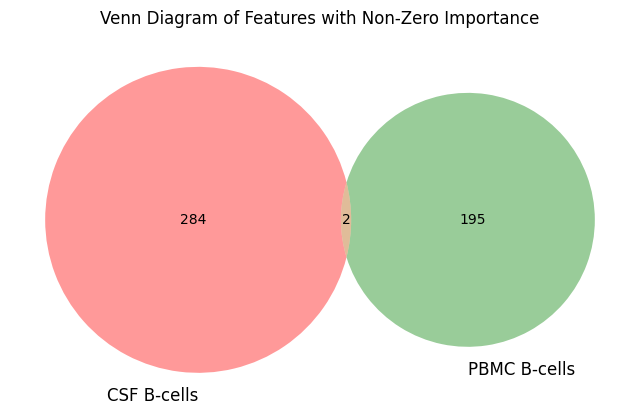

{'TMEM218', 'SAE1'}


In [33]:
# --- Venn Diagram ---
plt.figure(figsize=(8, 8))
venn2(
    subsets=(
        set(filtered_csf_importance.keys()),
        set(filtered_pbmc_importance.keys()),
    ),
    set_labels=("CSF B-cells", "PBMC B-cells"),
)
plt.title("Venn Diagram of Features with Non-Zero Importance")
plt.show()


# --- Importance Plot ---
# Find common features
common_features = set(filtered_csf_importance.keys()).intersection(
    filtered_pbmc_importance.keys()
)
print(common_features)

